# Backtesting Engine From Scratch

*ScientiaLab — open financial intelligence*

A backtest turns a trading idea into a number: if you had followed this rule on
this data, what would have happened? This notebook builds the mechanics of a
**vectorized backtest** from first principles — no backtesting library, just
pandas — using a simple moving-average crossover as the example strategy.

The point of this notebook is not the strategy. It is the **plumbing**: how a
signal becomes a position, how a position becomes a return stream, how easy it
is to accidentally cheat with lookahead bias, and how a few basis points of
cost can change the story. Those mechanics are the same regardless of what
generates the signal.

> **Educational tool only.** This notebook does not constitute financial
> advice. Sample data is synthetic. The strategy shown is a textbook example
> chosen for clarity, not a recommendation.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)


## 2. Synthetic price data

Same zero-dependency generator used in the Stacked-Uptrend Screener notebook —
no API key, no internet, fully reproducible. Swap it for a real data source
later without changing anything downstream.


In [3]:
def generate_ohlc(ticker, days=750, trend="mixed", volatility="normal", seed=0):
    """Configurable synthetic daily OHLCV generator with zero external
    dependencies — no API, no key, no rate limit, never breaks."""
    rs = np.random.default_rng(abs(hash((ticker, seed))) % (2**32))
    n = days
    sigma = {"low": 0.006, "normal": 0.012, "high": 0.024}[volatility]

    if trend == "up":
        mu = np.full(n, 0.0006)
    elif trend == "down":
        mu = np.full(n, -0.0006)
    elif trend == "choppy":
        mu = np.zeros(n)
    else:  # "mixed"
        split = n - n // 3
        mu = np.concatenate([np.full(split, 0.0001), np.full(n - split, 0.0009)])

    drift = rs.normal(mu, sigma)
    price0 = 40 + rs.uniform(0, 60)
    closes = price0 * np.exp(np.cumsum(drift))

    dates = pd.bdate_range(end=pd.Timestamp.today(), periods=n)
    high = closes * (1 + rs.uniform(0.002, 0.014, n))
    low = closes * (1 - rs.uniform(0.002, 0.014, n))
    open_ = closes * (1 + rs.normal(0, 0.004, n))
    volume = rs.integers(1_000_000, 9_000_000, n)

    return pd.DataFrame(
        {"open": open_, "high": high, "low": low, "close": closes, "volume": volume},
        index=dates,
    )

prices = generate_ohlc("DEMO", days=750, trend="mixed", volatility="normal", seed=7)
prices.tail()


,open,high,low,close,volume
2026-08-17,160.484154,161.992957,158.822839,160.824965,2912412
2026-08-18,162.109014,162.855976,160.385705,161.365679,8471668
2026-08-19,161.069711,162.794097,160.961862,161.544844,8485428
2026-08-20,162.225308,163.963594,161.797872,163.167627,6429471
2026-08-21,162.756829,162.396562,160.838217,161.784643,4708882


## 3. A simple signal: moving-average crossover

The classic textbook example: go long when a fast moving average is above a
slow one, stay flat otherwise. This is not how any real system trades — it is
chosen because the signal itself is trivial, so nothing distracts from the
backtest mechanics.


In [5]:
fast_window, slow_window = 20, 100

close = prices["close"]
fast_ma = close.rolling(fast_window).mean()
slow_ma = close.rolling(slow_window).mean()

signal = (fast_ma > slow_ma).astype(int)
signal.tail()


2026-08-17    0
2026-08-18    0
2026-08-19    0
2026-08-20    0
2026-08-21    0
Freq: B, Name: close, dtype: int32

## 4. From signal to position: avoiding lookahead bias

This is the step where backtests most often quietly cheat. A signal computed
from *today's* close is not known until *after* today's close — you cannot
trade on it until the next session. Skipping the shift below lets the backtest
"trade" on information it would not actually have had yet.


In [8]:
position = signal.shift(1).fillna(0)

# Without the shift, the backtest assumes it can act on today's close using
# today's close — impossible in live trading. Keep both to compare later.
position_no_shift = signal.fillna(0)


## 5. From position to returns: the equity curve

In [10]:
daily_returns = close.pct_change().fillna(0)

strategy_returns = position * daily_returns
benchmark_returns = daily_returns  # buy-and-hold

strategy_equity = (1 + strategy_returns).cumprod()
benchmark_equity = (1 + benchmark_returns).cumprod()

pd.DataFrame({"strategy": strategy_equity, "buy_and_hold": benchmark_equity}).tail()


,strategy,buy_and_hold
2026-08-17,1.657349,1.625537
2026-08-18,1.657349,1.631003
2026-08-19,1.657349,1.632814
2026-08-20,1.657349,1.649216
2026-08-21,1.657349,1.635237


## 6. Performance metrics, from scratch

Three standard, textbook metrics — no library, just their formulas:

- **CAGR**: compound annual growth rate over the sample.
- **Annualized volatility**: daily return std, scaled by `sqrt(252)`.
- **Sharpe ratio**: annualized return divided by annualized volatility (risk-free rate assumed 0 for simplicity).
- **Max drawdown**: largest peak-to-trough decline in the equity curve.

These are the standard formulas anyone can look up — not a claim about any
live strategy's actual performance.


In [12]:
def performance_summary(returns, periods_per_year=252):
    equity = (1 + returns).cumprod()
    n_years = len(returns) / periods_per_year

    cagr = equity.iloc[-1] ** (1 / n_years) - 1
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = (returns.mean() * periods_per_year) / ann_vol if ann_vol > 0 else np.nan

    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_dd = drawdown.min()

    return {
        "CAGR": round(cagr, 4),
        "Annualized volatility": round(ann_vol, 4),
        "Sharpe (rf=0)": round(sharpe, 2),
        "Max drawdown": round(max_dd, 4),
    }

summary = pd.DataFrame({
    "strategy": performance_summary(strategy_returns),
    "buy_and_hold": performance_summary(benchmark_returns),
})
summary


,strategy,buy_and_hold
CAGR,0.1850,0.1797
Annualized volatility,0.1536,0.1880
Sharpe (rf=0),1.1800,0.9700
Max drawdown,-0.1047,-0.2664


## 7. Chart the equity curves

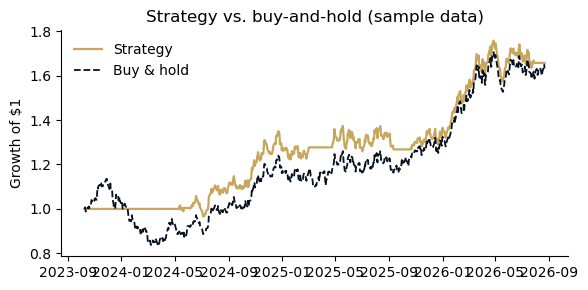

In [14]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(strategy_equity.index, strategy_equity, label="Strategy", color="#c8a75d", linewidth=1.6)
ax.plot(benchmark_equity.index, benchmark_equity, label="Buy & hold", color="#07111f", linewidth=1.3, linestyle="--")
ax.set_title("Strategy vs. buy-and-hold (sample data)")
ax.set_ylabel("Growth of $1")
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 8. Why backtests lie: common pitfalls

A clean equity curve is easy to produce and easy to be fooled by. A few of the
usual culprits:

- **Lookahead bias** — using information before it would actually have been
  available (Section 4). The most common and most damaging mistake.
- **Survivorship bias** — testing only on assets that still exist today,
  quietly excluding the ones that went to zero or got delisted.
- **Overfitting / curve-fitting** — tuning parameters (window lengths,
  thresholds) until the backtest looks great on one historical sample. A
  strategy fit to noise will not repeat out of sample.
- **Ignoring costs and slippage** — real trades pay the bid-ask spread,
  commissions, and market impact. A strategy that trades often can look
  profitable gross and unprofitable net.
- **Regime dependency** — a strategy tuned on a trending sample may fail
  completely in a choppy one, and vice versa. Always test across regimes, not
  just the one that happens to be convenient.

The cell below makes the first point concrete: compare the shifted (correct)
position against the unshifted (lookahead-biased) one on the same data.


In [17]:
naive_returns = position_no_shift * daily_returns
naive_equity = (1 + naive_returns).cumprod()

comparison = pd.DataFrame({
    "correctly shifted": performance_summary(strategy_returns),
    "lookahead-biased": performance_summary(naive_returns),
})
comparison


,correctly shifted,lookahead-biased
CAGR,0.1850,0.1832
Annualized volatility,0.1536,0.1529
Sharpe (rf=0),1.1800,1.1800
Max drawdown,-0.1047,-0.1047


## 9. A simple transaction cost model

Every time the position changes, assume a flat cost in basis points (bps) —
a stand-in for spread, commissions, and slippage combined. This is a
simplification, but it is enough to show that costs are not a rounding error.


In [19]:
cost_bps = 5  # 0.05% per position change, a simple illustrative assumption

turnover = position.diff().abs().fillna(0)
transaction_costs = turnover * (cost_bps / 10_000)

strategy_returns_net = strategy_returns - transaction_costs
strategy_equity_net = (1 + strategy_returns_net).cumprod()

cost_comparison = pd.DataFrame({
    "gross of costs": performance_summary(strategy_returns),
    f"net of {cost_bps}bps costs": performance_summary(strategy_returns_net),
})
cost_comparison


,gross of costs,net of 5bps costs
CAGR,0.1850,0.1834
Annualized volatility,0.1536,0.1536
Sharpe (rf=0),1.1800,1.1700
Max drawdown,-0.1047,-0.1047


From there, the natural next steps: swap `generate_ohlc` for the
Stacked-Uptrend Screener's signal instead of a moving-average crossover, test
across multiple synthetic regimes (`trend="up"`, `"down"`, `"choppy"`) rather
than a single sample, and replace the flat basis-point cost with a model that
scales with position size. The mechanics in this notebook — signal, shift,
position, return, cost — stay the same no matter what generates the signal.


---

**Disclaimer:** This notebook is an educational resource. It illustrates
backtesting mechanics and does not constitute investment advice, a
recommendation, or an offer to buy or sell any security. Sample data is
synthetic, and the strategy shown is a textbook example, not a live or
recommended trading system.

Built and shared by ScientiaLab, the open learning arm of
[Scientia Capital Management](https://www.scientiacapital.co.uk/).
